In [6]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = 'Electric_Vehicle_Population_Data.csv'  # Replace with your file path
data = pd.read_csv(file_path)

In [7]:
# Display basic dataset information
print("Dataset Information:")
print(data.info())
print("\nMissing Values:")
print(data.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(data.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   VIN (1-10)                                         50000 non-null  object
 1   County                                             50000 non-null  object
 2   City                                               50000 non-null  object
 3   State                                              50000 non-null  object
 4   Postal Code                                        50000 non-null  int64 
 5   Model Year                                         50000 non-null  int64 
 6   Make                                               50000 non-null  object
 7   Model                                              50000 non-null  object
 8   Electric Vehicle Type                              50000 non-null  object
 

In [9]:
# Checking unique values in categorical columns
categorical_columns = ['County', 'City', 'State', 'Make', 'Model', 'Electric Vehicle Type']
for col in categorical_columns:
    print(f"\nUnique values in {col}: {data[col].nunique()}")


Unique values in County: 20

Unique values in City: 152

Unique values in State: 1

Unique values in Make: 38

Unique values in Model: 132

Unique values in Electric Vehicle Type: 2


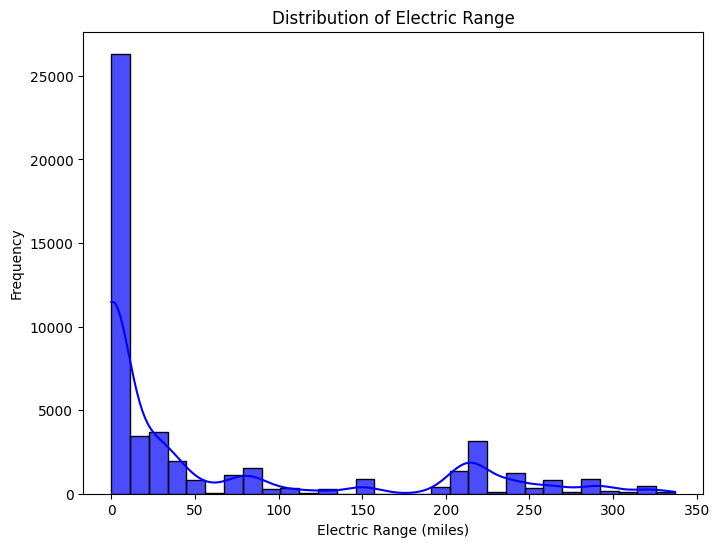

<ipython-input-10-c5ad55015fb1>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Electric Vehicle Type', data=data, palette='muted', order=data['Electric Vehicle Type'].value_counts().index)


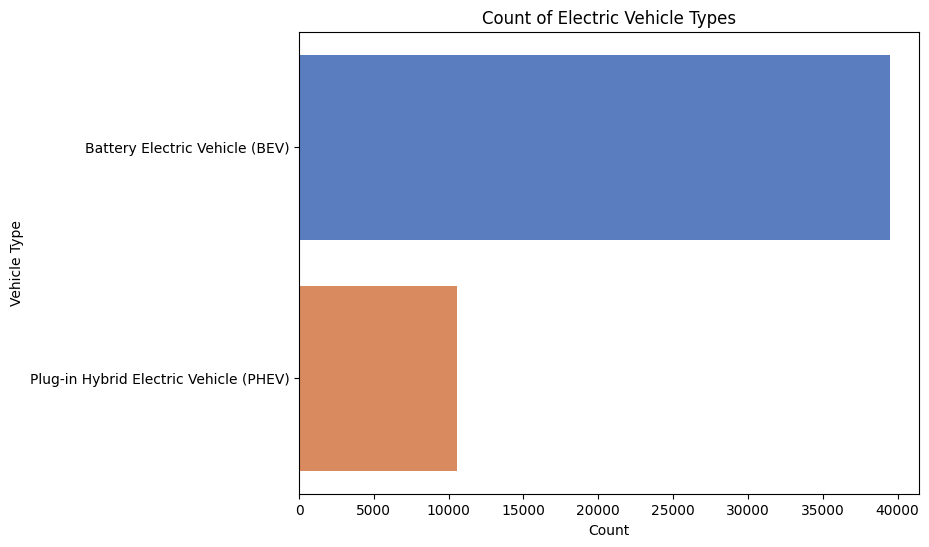

<ipython-input-10-c5ad55015fb1>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.values, y=top_makes.index, palette='coolwarm')


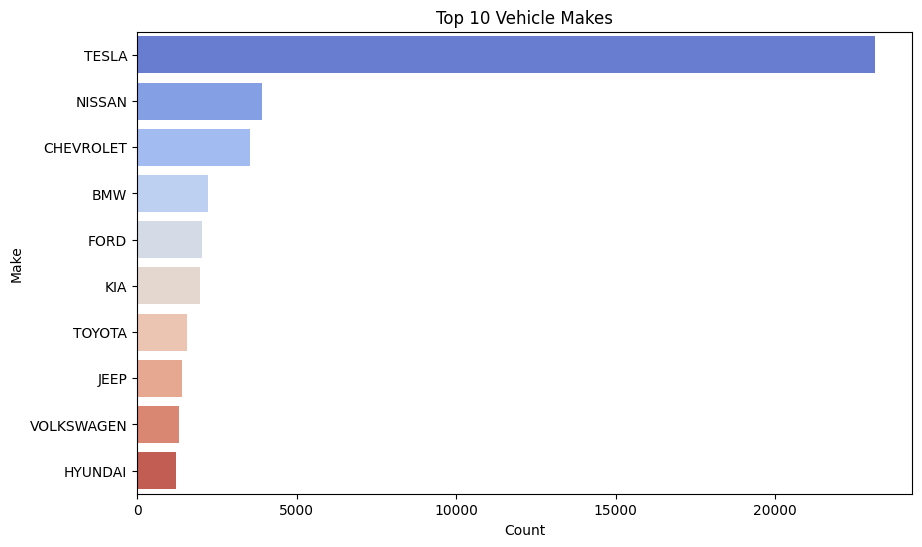

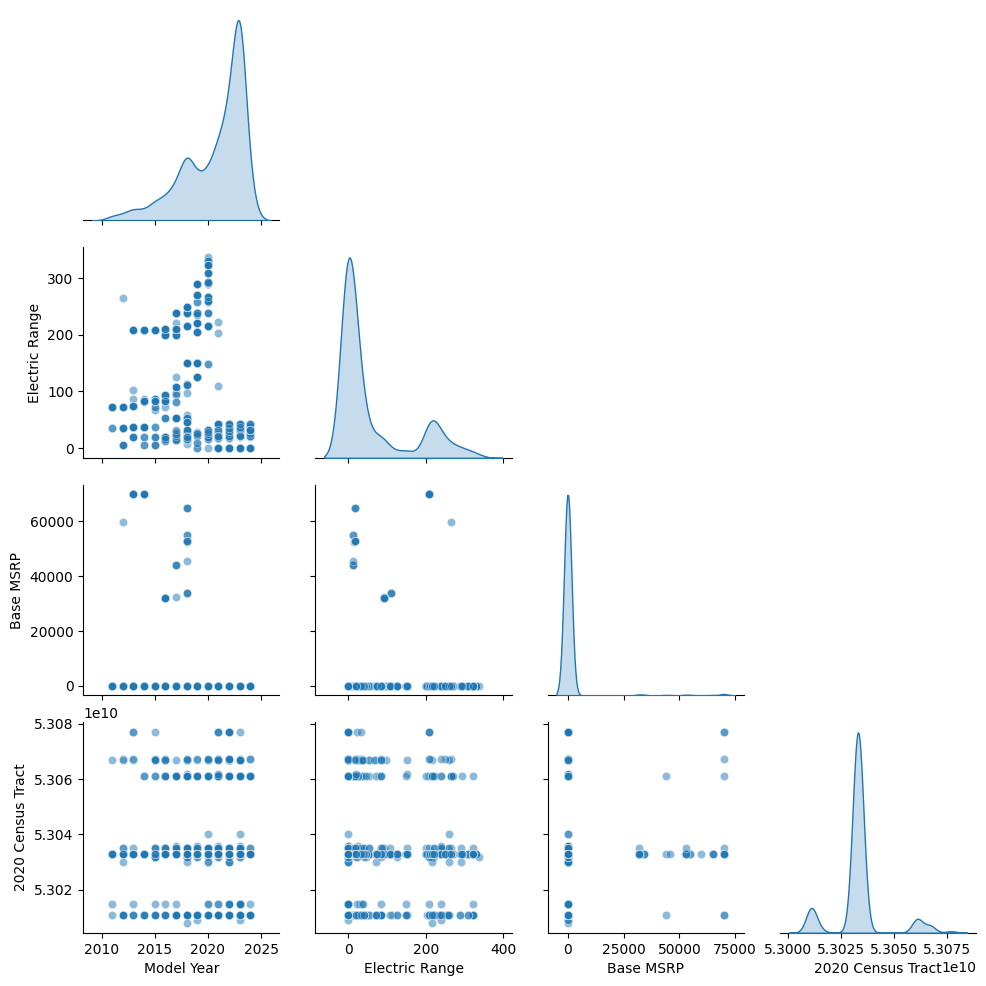

<ipython-input-10-c5ad55015fb1>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values, y=top_models.index, palette='coolwarm')


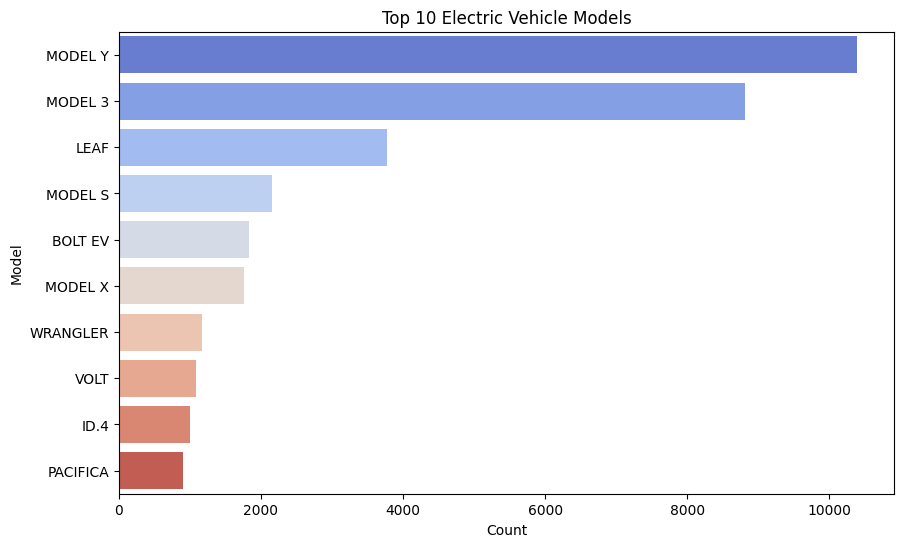

<ipython-input-10-c5ad55015fb1>:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data[data['County'].isin(top_counties)], y='County', palette='viridis', order=top_counties)


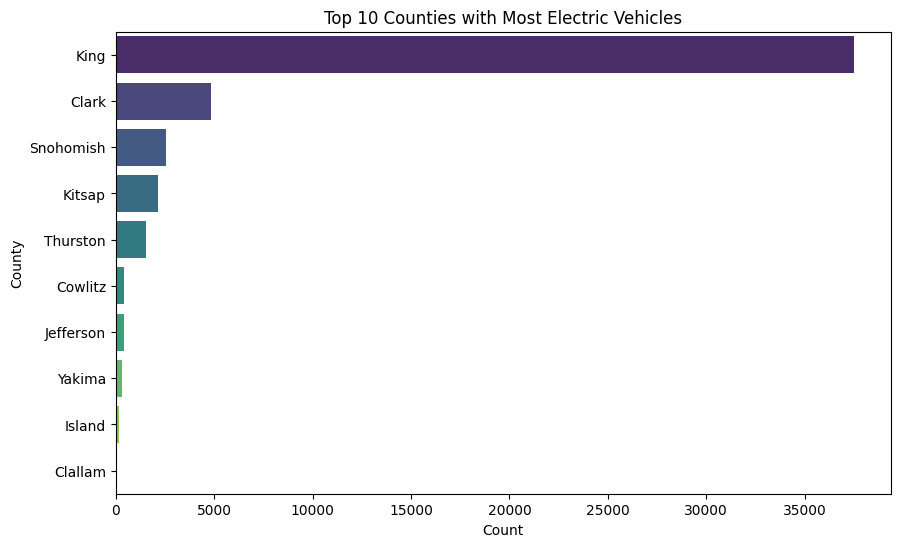

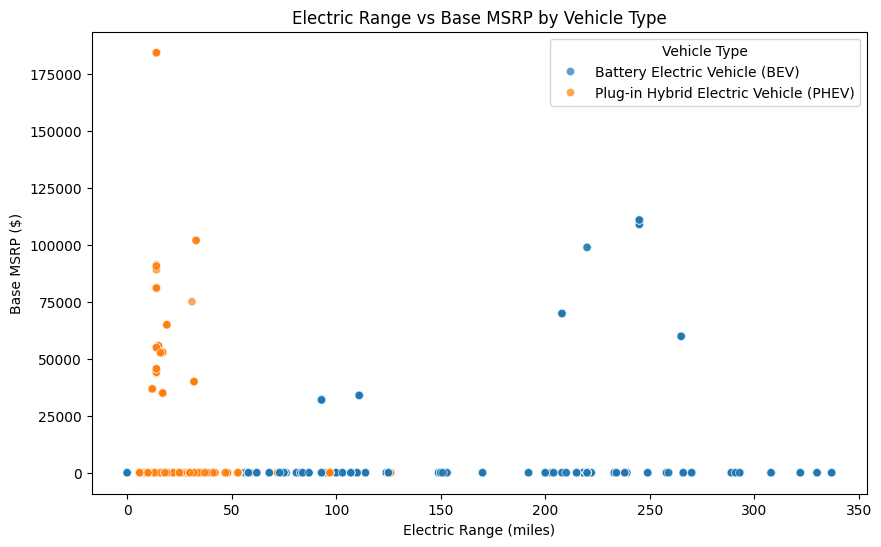

In [10]:
# Distribution of Electric Range
plt.figure(figsize=(8, 6))
sns.histplot(data['Electric Range'], kde=True, bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Frequency')
plt.show()

# Count plot for Electric Vehicle Type
plt.figure(figsize=(8, 6))
sns.countplot(y='Electric Vehicle Type', data=data, palette='muted', order=data['Electric Vehicle Type'].value_counts().index)
plt.title('Count of Electric Vehicle Types')
plt.xlabel('Count')
plt.ylabel('Vehicle Type')
plt.show()

# Top 10 Vehicle Makes
top_makes = data['Make'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_makes.values, y=top_makes.index, palette='coolwarm')
plt.title('Top 10 Vehicle Makes')
plt.xlabel('Count')
plt.ylabel('Make')
plt.show()

# Scatterplot matrix for numeric columns
numeric_columns = ['Model Year', 'Electric Range', 'Base MSRP', '2020 Census Tract']
sampled_data = data[numeric_columns].sample(2000, random_state=42)  # Sampling for efficiency
sns.pairplot(sampled_data, diag_kind='kde', corner=True, plot_kws={'alpha': 0.5})
plt.show()

# Top models in the dataset
top_models = data['Model'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_models.values, y=top_models.index, palette='coolwarm')
plt.title('Top 10 Electric Vehicle Models')
plt.xlabel('Count')
plt.ylabel('Model')
plt.show()

# Distribution of vehicle makes across top counties
top_counties = data['County'].value_counts().head(10).index
plt.figure(figsize=(10, 6))
sns.countplot(data=data[data['County'].isin(top_counties)], y='County', palette='viridis', order=top_counties)
plt.title('Top 10 Counties with Most Electric Vehicles')
plt.xlabel('Count')
plt.ylabel('County')
plt.show()

# Electric Range vs Base MSRP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Electric Range', y='Base MSRP', hue='Electric Vehicle Type', alpha=0.7)
plt.title('Electric Range vs Base MSRP by Vehicle Type')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Base MSRP ($)')
plt.legend(title='Vehicle Type')
plt.show()

In [3]:
import folium
from folium.plugins import HeatMap

# Load dataset (replace with your file path)
file_path = 'Electric_Vehicle_Population_Data.csv'  # Update with the actual file path
data = pd.read_csv(file_path)

# Extract Latitude and Longitude from 'Vehicle Location'
data[['Longitude', 'Latitude']] = data['Vehicle Location'].str.extract(r'POINT \(([-\d\.]+) ([-\d\.]+)\)')
data['Latitude'] = pd.to_numeric(data['Latitude'], errors='coerce')
data['Longitude'] = pd.to_numeric(data['Longitude'], errors='coerce')

# Drop rows with NaN values in Latitude or Longitude
location_data = data[['Latitude', 'Longitude']].dropna()

# Create a map centered at the mean location
location_map = folium.Map(location=[location_data['Latitude'].mean(), location_data['Longitude'].mean()], zoom_start=7)

# Add heatmap layer
HeatMap(location_data.values, radius=10).add_to(location_map)

# Save map to an HTML file
location_map.save('location_heatmap.html')
print("Location heatmap saved as 'location_heatmap.html'.")



Location heatmap saved as 'location_heatmap.html'.


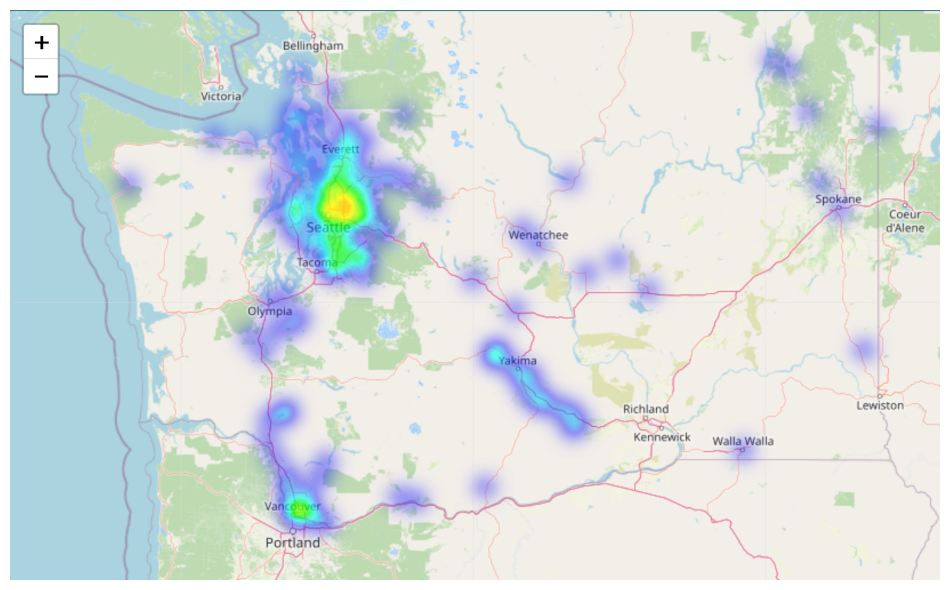

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

# Open the image
img = Image.open('heatmap_locations.png')  # Use the uploaded image's filename

plt.figure(figsize=(12, 8))
# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axis

plt.show()